# NB02 — Validación del pipeline sobre un estudio real

**TFM · Máster Universitario en Inteligencia Artificial · VIU 2025-2026 · Víctor Rodríguez Rodríguez**

---

## Propósito
Validar sobre un único estudio real de VinDr-Mammo el pipeline completo (DICOM - preprocesado - backbone - Punto A - Punto B con stretch - reducción GAP + GMP) antes de lanzar la extracción masiva sobre los 5.000 estudios en el NB03.

**Inputs**: `AsymMirai/snapshots/trained_asymmirai.pt`, un archivo DICOM de `Data/vindr-mammo/images/`.

---

## Etapas del pipeline validadas

1. **DICOM - tensor preprocesado**: lectura del archivo, rescalado lineal, Window/Level, inversión de fotometría, alineación por centroide, redimensionado bilineal a `(1664, 2048)` y normalización tipo Mirai.
2. **Backbone - embeddings**: paso de las 4 vistas por el backbone congelado para obtener el Punto A.
3. **Cálculo de Punto B**: aplicación de los pesos de `stretch` por canal y cálculo de `|L − R|` por par bilateral.
4. **Reducción GAP+GMP**: conversión de cada embedding `(1, 512, 52, 64)` en un vector `(1, 1024)`.


In [1]:
import os, sys, time
import numpy as np
import pandas as pd
import torch
import cv2
import pydicom

BASE = os.environ.get('TFM_PROJECT_ROOT', os.path.abspath(os.path.join(os.getcwd(), '..')))
ASYMMIRAI = os.path.join(BASE, 'AsymMirai')
DATA = os.path.join(BASE, 'Data', 'vindr-mammo')
WEIGHTS = os.path.join(ASYMMIRAI, 'snapshots', 'trained_asymmirai.pt')
IMG_DIR = os.path.join(DATA, 'images')
BREAST_CSV = os.path.join(DATA, 'breast-level_annotations.csv')

sys.path.insert(0, ASYMMIRAI)
sys.path.insert(0, os.path.join(ASYMMIRAI, 'asymmetry_model'))

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## 1. Cargar AsymMirai y extraer los parámetros de stretch

El modelo se congela  y se guarda a parte los `cc_stretch_params` y `mlo_stretch_params`, que son vectores de 512 valores aprendidos por canal que el modelo aplica antes de comparar L con R.

In [2]:
model = torch.load(WEIGHTS, map_location=DEVICE, weights_only=False)
model.eval()
for p in model.parameters():
    p.requires_grad = False

ALIGN_SPACE = getattr(model, 'alignment_space', None)
USE_STRETCH = getattr(model, 'use_stretch', False)

print(f'alignment_space = {ALIGN_SPACE}, use_stretch = {USE_STRETCH}')

if USE_STRETCH:
    cc_stretch = model.cc_stretch_params.detach()
    mlo_stretch = model.mlo_stretch_params.detach()
    print(f'cc_stretch_params shape={tuple(cc_stretch.shape)}, rango=[{cc_stretch.min():.3f}, {cc_stretch.max():.3f}]')
    print(f'mlo_stretch_params shape={tuple(mlo_stretch.shape)}, rango=[{mlo_stretch.min():.3f}, {mlo_stretch.max():.3f}]')
else:
    cc_stretch = mlo_stretch = None

c:\Users\victo\miniconda3\envs\tfm\Lib\site-packages\torch\serialization.py:1782: SourceChangeWarning: source code of class 'mirai_localized_dif_head.LocalizedDifModel' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  _check_container_source(*data)
c:\Users\victo\miniconda3\envs\tfm\Lib\site-packages\torch\serialization.py:1782: SourceChangeWarning: source code of class 'torch.nn.modules.container.Sequential' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  _check_container_source(*data)


alignment_space = None, use_stretch = True
cc_stretch_params shape=(512,), rango=[-0.000, 4.586]
mlo_stretch_params shape=(512,), rango=[-0.000, 5.306]


## 2. Pipeline DICOM - tensor preprocesado

Cada DICOM pasa por estas transformaciones (en este orden):

### Carga DICOM con `load_dicom`
- Lee el archivo y obtiene la matriz de píxeles.
- Aplica la transformación lineal `slope*p + intercept` (estándar DICOM para llevar los píxeles a unidades físicas).
- Si hay metadatos de Window/Level (centro y ancho de la ventana de visualización), recorta el rango de píxeles a ese intervalo.
- Si la foto está invertida (`PhotometricInterpretation == 'MONOCHROME1'`, fondo claro), la invierte para que el fondo quede oscuro.

### Alineación con `align_by_centroid`
- Calcula el centroide del tejido mamario.
- Traslada la imagen para que el centroide quede en el centro del campo de visión.
Las mamografías pueden venir con la mama pegada a uno de los bordes, centrarla reduce variabilidad espuria.

### Resize bilineal a (1664, 2048)
El backbone fue entrenado a este tamaño exacto. Si cambiamos, los embeddings serán inútiles.

### Normalización tipo Mirai
`(img - 7699.5) / 11765.06` con la media y desviación de Mirai. Sin esto los píxeles no caen en el rango con el que el backbone fue entrenado.

### Triplicar canales y añadir dimensión batch
Se obtiene un tensor `(1, 3, 1664, 2048)` listo para el backbone.

In [3]:
MIRAI_MEAN = 7699.5
MIRAI_STD  = 11765.06
TARGET_H, TARGET_W = 1664, 2048

def load_dicom(path):
    ds = pydicom.dcmread(path)
    pixels = ds.pixel_array.astype(np.float32)
    # Transformación lineal estándar DICOM
    pixels = pixels * float(getattr(ds, 'RescaleSlope', 1)) + float(getattr(ds, 'RescaleIntercept', 0))
    # Window/Level si está disponible
    if hasattr(ds, 'WindowCenter') and hasattr(ds, 'WindowWidth'):
        wc = float(ds.WindowCenter[0]) if hasattr(ds.WindowCenter, '__iter__') else float(ds.WindowCenter)
        ww = float(ds.WindowWidth[0])  if hasattr(ds.WindowWidth,  '__iter__') else float(ds.WindowWidth)
        pixels = np.clip(pixels, wc-ww/2, wc+ww/2)
    # Invertir si fondo claro
    if getattr(ds, 'PhotometricInterpretation', '') == 'MONOCHROME1':
        pixels = pixels.max() - pixels
    return pixels

def align_by_centroid(img):
    h, w = img.shape
    mask = (img > img.mean()).astype(np.uint8)
    M = cv2.moments(mask)
    if M['m00'] == 0:
        return img  # imagen vacía o casi vacía: no la movemos
    cy, cx = int(M['m01']/M['m00']), int(M['m10']/M['m00'])
    M_aff = np.float32([[1, 0, w//2-cx], [0, 1, h//2-cy]])
    return cv2.warpAffine(img, M_aff, (w, h), borderValue=0)

def preprocess_view(dcm_path):
    img = load_dicom(dcm_path)
    img = align_by_centroid(img)
    img = cv2.resize(img, (TARGET_W, TARGET_H), interpolation=cv2.INTER_LINEAR)
    img = (img - MIRAI_MEAN) / MIRAI_STD
    img = np.stack([img, img, img], axis=0)[None, ...] 
    return torch.from_numpy(img).float()

## 3. Cargar el CSV de etiquetas y construir la etiqueta a nivel estudio

En el datasetr VinDr-Mammo el fichero `breast-level_annotations.csv` trae 4 filas por estudio (una por L/R × CC/MLO). El BI-RADS está asignado a la mama, no a la vista, así que CC y MLO de la misma mama típicamente comparten BI-RADS.

Agregamos al nivel estudio con el max BI-RADS de las 4 vistas: si cualquier mama es sospechosa (BI-RADS ≥ 4), el estudio se etiqueta sospechoso.

El parser del BI-RADS convierte el formato string (`'BI-RADS 4'`) a entero (`4`).

In [4]:
df = pd.read_csv(BREAST_CSV)
print(f'Filas: {len(df):,}')
print(f'Columnas: {df.columns.tolist()}')

def parse_birads(v):
    if isinstance(v, str):
        s = v.replace('BI-RADS', '').replace('BIRADS', '').strip()
        try: return int(s)
        except: return np.nan
    return int(v) if not pd.isna(v) else np.nan

df['birads_int'] = df['breast_birads'].apply(parse_birads)

study_agg = df.groupby('study_id').agg( max_birads = ('birads_int', 'max'), split = ('split', 'first')).reset_index()

study_agg['y_estudio'] = (study_agg['max_birads'] >= 4).astype(int)

print(f'\nEstudios totales: {len(study_agg)}')
print(f'Distribución de max BI-RADS por estudio: {study_agg.max_birads.value_counts().sort_index().to_dict()}')
print(f'Etiqueta y_estudio=1 (BI-RADS ≥ 4): {study_agg.y_estudio.sum()} estudios ({100*study_agg.y_estudio.mean():.2f}%)')

Filas: 20,000
Columnas: ['study_id', 'series_id', 'image_id', 'laterality', 'view_position', 'height', 'width', 'breast_birads', 'breast_density', 'split']

Estudios totales: 5000
Distribución de max BI-RADS por estudio: {1: 2515, 2: 1568, 3: 436, 4: 368, 5: 113}
Etiqueta y_estudio=1 (BI-RADS ≥ 4): 481 estudios (9.62%)


## 4. Elegir un estudio positivo para validar

Se elige un estudio con max BI-RADS ≥ 4 para verificar que el cálculo de asimetría también funciona en un caso "interesante".

In [5]:
estudios_pos = study_agg[study_agg.y_estudio == 1]['study_id'].tolist()
study_id = estudios_pos[0]
max_b = int(study_agg[study_agg.study_id == study_id].max_birads.iloc[0])
print(f'Estudio elegido: {study_id}, max BI-RADS = {max_b}')

Estudio elegido: 003700f3c960e0b9bca2b8437c3dbf05, max BI-RADS = 4


## 5. Localizar las 4 vistas en disco

Estructura real: `Data\vindr-mammo\images\{study_id}\{image_id}.dicom`. Construimos un diccionario `(laterality, view)` que mapea a la ruta del DICOM y verificamos que las 4 vistas existen.

In [6]:
df_study = df[df.study_id == study_id]
print(df_study[['image_id', 'laterality', 'view_position', 'breast_birads']])

vistas = {}
for _, row in df_study.iterrows():
    k = (row['laterality'], row['view_position'])
    vistas[k] = os.path.join(IMG_DIR, study_id, f'{row["image_id"]}.dicom')

print('\nVerificación de existencia en disco:')
for k, p in vistas.items():
    print(f'{"OK" if os.path.isfile(p) else "FALTA"} {k}: {p}')

assert all(os.path.isfile(p) for p in vistas.values()), 'Faltan vistas'

                              image_id laterality view_position breast_birads
9744  51b47f9024ccad1356354f56ac916f29          L            CC     BI-RADS 4
9745  3944b33b99c98e763763b9da54b4f41c          L           MLO     BI-RADS 4
9746  17c3d032d611eb3d1baf3434d62483a1          R            CC     BI-RADS 1
9747  552a67df6d68b8f9498db7cadd23b0e0          R           MLO     BI-RADS 1

Verificación de existencia en disco:
OK ('L', 'CC'): c:\Users\victo\Documents\TFM\Proyecto\Data\vindr-mammo\images\003700f3c960e0b9bca2b8437c3dbf05\51b47f9024ccad1356354f56ac916f29.dicom
OK ('L', 'MLO'): c:\Users\victo\Documents\TFM\Proyecto\Data\vindr-mammo\images\003700f3c960e0b9bca2b8437c3dbf05\3944b33b99c98e763763b9da54b4f41c.dicom
OK ('R', 'CC'): c:\Users\victo\Documents\TFM\Proyecto\Data\vindr-mammo\images\003700f3c960e0b9bca2b8437c3dbf05\17c3d032d611eb3d1baf3434d62483a1.dicom
OK ('R', 'MLO'): c:\Users\victo\Documents\TFM\Proyecto\Data\vindr-mammo\images\003700f3c960e0b9bca2b8437c3dbf05\552a67df6

## 6. Preprocesar las 4 vistas y pasarlas por el backbone

Cada vista pasa por el preprocesado y luego por `model.backbone()`. La salida es el embedding `(1, 512, 52, 64)` por vista. Esto corresponde con el Punto A, los 4 embeddings (uno por vista) sin asimetría aplicada.

In [7]:
t0 = time.time()
l_cc  = preprocess_view(vistas[('L', 'CC')]).to(DEVICE)
r_cc  = preprocess_view(vistas[('R', 'CC')]).to(DEVICE)
l_mlo = preprocess_view(vistas[('L', 'MLO')]).to(DEVICE)
r_mlo = preprocess_view(vistas[('R', 'MLO')]).to(DEVICE)
print(f'Preprocesado 4 vistas: {time.time()-t0:.2f}s')

t0 = time.time()
with torch.no_grad():
    emb_l_cc  = model.backbone(l_cc)
    emb_r_cc  = model.backbone(r_cc)
    emb_l_mlo = model.backbone(l_mlo)
    emb_r_mlo = model.backbone(r_mlo)
print(f'Backbone (4 vistas): {time.time()-t0:.2f}s')

for nm, t in [('L_CC', emb_l_cc), ('R_CC', emb_r_cc), ('L_MLO', emb_l_mlo), ('R_MLO', emb_r_mlo)]:
    print(f'PUNTO A — emb_{nm}: shape={tuple(t.shape)}')

Preprocesado 4 vistas: 0.45s
Backbone (4 vistas): 0.12s
PUNTO A — emb_L_CC: shape=(1, 512, 52, 64)
PUNTO A — emb_R_CC: shape=(1, 512, 52, 64)
PUNTO A — emb_L_MLO: shape=(1, 512, 52, 64)
PUNTO A — emb_R_MLO: shape=(1, 512, 52, 64)


## 7. Calcular el Punto B (asimetría bilateral con stretch)

El cálculo replica los dos primeros pasos de lo que `LocalizedDifModel.asymmetry_metric()` (la función `hybrid_asymmetry` del repositorio oficial) hace internamente:

1. Aplica los pesos por canal aprendidos: `L_stretched = stretch * L_emb`, lo mismo con R.
2. Calcula la diferencia absoluta: `asym = |L_stretched − R_stretched|`.

Lo que el código oficial hace después y que en este caso no se replica: 
- MaxPool2D flexible con kernel (10, 12) y stride (1, 1).
- `torch.norm(dim=-3)` que colapsa los 512 canales en una norma L2 por posición espacial (dejando un mapa 2D)
- Máximo global sobre ese mapa 2D, devolviendo un escalar. 
El score escalar final de AsymMirai surge de promediar el resultado de CC y MLO, normalizarlo con (mean=40, std=10) aprendidos y aplicar sigmoide.

Se preserva el mapa de asimetría con sus 512 canales y se reduce con GAP+GMP igual que el Punto A. Esto produce un vector de 1.024 dimensiones por mapa, sustancialmente más informativo que el escalar que el modelo original produce. El objetivo no es reproducir el score de riesgo a 1-5 años de AsymMirai (no tenemos seguimiento longitudinal en VinDr-Mammo), sino aprovechar las representaciones internas de asimetría para una tarea distinta (clasificación binaria BI-RADS).

El stretch es distinto por vista (CC tiene sus pesos, MLO los suyos), porque el modelo aprendió que la información discriminativa de la asimetría se distribuye distinto en las dos proyecciones.

In [8]:
def compute_asym(left_emb, right_emb, stretch_params=None):
    # Calcula la diferencia absoluta entre mamas sobre los embeddings, aplicando opcionalmente los pesos de stretch canal a canal antes de la sustracción.
    if stretch_params is not None:
        # Broadcasting
        sp = stretch_params.view(1, -1, 1, 1).to(left_emb.device)
        left_emb = sp * left_emb
        right_emb = sp * right_emb
    return torch.abs(left_emb - right_emb)

with torch.no_grad():
    asym_cc = compute_asym(emb_l_cc,  emb_r_cc,  cc_stretch  if USE_STRETCH else None)
    asym_mlo = compute_asym(emb_l_mlo, emb_r_mlo, mlo_stretch if USE_STRETCH else None)

print(f'PUNTO B — asym_CC : shape={tuple(asym_cc.shape)}, media={asym_cc.mean():.4f}, max={asym_cc.max():.4f}')
print(f'PUNTO B — asym_MLO: shape={tuple(asym_mlo.shape)}, media={asym_mlo.mean():.4f}, max={asym_mlo.max():.4f}')

PUNTO B — asym_CC : shape=(1, 512, 52, 64), media=0.0009, max=1.8370
PUNTO B — asym_MLO: shape=(1, 512, 52, 64), media=0.0009, max=1.2684


## 8. Reducción GAP + GMP — la misma para los dos puntos

Se aplica la misma reducción a Punto A y Punto B. Si usáramos GAP solo para A y GMP solo para B, no sabríamos si las diferencias en AUC vienen del contenido informativo o del método de pooling.

Cada vector pooleado tiene 1024 dims (512 GAP + 512 GMP), un vector por vista o por par bilateral.

In [9]:
def pool_features(x):
    # GAP captura magnitud media (información global), GMP captura el pico (información local).
    gap = x.mean(dim=(-2, -1))
    gmp = x.amax(dim=(-2, -1))
    return torch.cat([gap, gmp], dim=1)

feat_l_cc = pool_features(emb_l_cc)
feat_r_cc = pool_features(emb_r_cc)
feat_l_mlo = pool_features(emb_l_mlo)
feat_r_mlo = pool_features(emb_r_mlo)
feat_asym_cc = pool_features(asym_cc)
feat_asym_mlo = pool_features(asym_mlo)

print(f'Punto A — feat_L_CC: shape={tuple(feat_l_cc.shape)}, rango=[{feat_l_cc.min():.2f}, {feat_l_cc.max():.2f}]')
print(f'Punto A — feat_R_CC: shape={tuple(feat_r_cc.shape)}, rango=[{feat_r_cc.min():.2f}, {feat_r_cc.max():.2f}]')
print(f'Punto A — feat_L_MLO: shape={tuple(feat_l_mlo.shape)}, rango=[{feat_l_mlo.min():.2f}, {feat_l_mlo.max():.2f}]')
print(f'Punto A — feat_R_MLO: shape={tuple(feat_r_mlo.shape)}, rango=[{feat_r_mlo.min():.2f}, {feat_r_mlo.max():.2f}]')
print(f'Punto B — feat_asym_CC: shape={tuple(feat_asym_cc.shape)}, rango=[{feat_asym_cc.min():.3f}, {feat_asym_cc.max():.3f}]')
print(f'Punto B — feat_asym_MLO: shape={tuple(feat_asym_mlo.shape)}, rango=[{feat_asym_mlo.min():.3f}, {feat_asym_mlo.max():.3f}]')

Punto A — feat_L_CC: shape=(1, 1024), rango=[0.00, 2.73]
Punto A — feat_R_CC: shape=(1, 1024), rango=[0.00, 2.70]
Punto A — feat_L_MLO: shape=(1, 1024), rango=[0.00, 2.70]
Punto A — feat_R_MLO: shape=(1, 1024), rango=[0.00, 2.70]
Punto B — feat_asym_CC: shape=(1, 1024), rango=[0.000, 1.837]
Punto B — feat_asym_MLO: shape=(1, 1024), rango=[0.000, 1.268]


## 9. Construcción de los inputs — configuraciones base validadas aquí

Los 6 vectores de 1024 dims (4 vistas + 2 mapas de asimetría) permiten construir por concatenación las tres configuraciones fundamentales del trabajo, que sirven como base para el pipeline final:

- E-A (estudio, Punto A) = concat(L-CC, R-CC, L-MLO, R-MLO), 4096 dims.
- E-B (estudio, Punto B) = concat(asym-CC, asym-MLO), 2048 dims.
- M-A (mama, Punto A) = un vector por mama = concat(CC, MLO) de esa mama, 2048 dims.

Sobre este esqueleto se construyen posteriormente las 10 configuraciones definitivas cruzando estas variantes con la combinación A+B (Punto A y Punto B concatenados) y la estrategia de pooling alternativa (pool adaptativo 2×2 en lugar de GAP+GMP).

Esta separación entre extracción (cara, en GPU) y construcción del input (barata, en RAM) es la clave del diseño. Se extrae una sola vez por estrategia de pooling y se recomponen las configuraciones que se necesiten.


In [10]:
x_E_A = torch.cat([feat_l_cc, feat_r_cc, feat_l_mlo, feat_r_mlo], dim=1)
x_E_B = torch.cat([feat_asym_cc, feat_asym_mlo], dim=1)
x_M_A_L = torch.cat([feat_l_cc, feat_l_mlo], dim=1)
x_M_A_R = torch.cat([feat_r_cc, feat_r_mlo], dim=1)

print(f'E-A (estudio, Punto A): shape={tuple(x_E_A.shape)}, 4 vistas * 1024 dims')
print(f'E-B (estudio, Punto B): shape={tuple(x_E_B.shape)}, 2 pares * 1024 dims')
print(f'M-A izquierda (mama): shape={tuple(x_M_A_L.shape)}, 2 vistas * 1024 dims')
print(f'M-A derecha   (mama): shape={tuple(x_M_A_R.shape)}, 2 vistas * 1024 dims')

E-A (estudio, Punto A): shape=(1, 4096), 4 vistas * 1024 dims
E-B (estudio, Punto B): shape=(1, 2048), 2 pares * 1024 dims
M-A izquierda (mama): shape=(1, 2048), 2 vistas * 1024 dims
M-A derecha   (mama): shape=(1, 2048), 2 vistas * 1024 dims


## 10. Visualización de las etapas del preprocesado

Para ilustrar las transformaciones que sufre una vista DICOM antes de entrar al backbone, se instrumenta el pipeline de preprocesado para capturar la imagen en cada etapa intermedia.

Las cinco etapas visualizadas son:

1. **DICOM crudo**. Matriz de píxeles tras `pydicom.dcmread` y aplicación de `RescaleSlope`/`RescaleIntercept`.
2. **Window/Level + fotometría**. Recorte al rango clínicamente relevante `[WC − WW/2, WC + WW/2]` e inversión de MONOCHROME1 si aplica.
3. **Alineación por centroide**. Traslación de la imagen para que el centroide del tejido mamario quede en el centro del campo de visión.
4. **Redimensionado**. Interpolación bilineal a `(1664, 2048)`, el tamaño de entrada esperado por el backbone.
5. **Normalización tipo Mirai**. Resta la media y divide por la desviación estándar heredadas del entrenamiento original de Mirai sobre EMBED (media 7699,5; desviación 11765,06).

**NOTA**: Para visualización se usa una variante local con borderValue = valor de fondo (mínimo tras W/L) en lugar del 0 hardcodeado en align_by_centroid. Esto evita un artefacto visual del autoescalado de imshow en el que si el fondo tras W/L es 893 y warpAffine introduce nuevas zonas a 0, imshow reescala y el fondo original pasa de verse negro a verse gris, generando un "recuadro gris fantasma" en las etapas 3, 4 y 5. Con borderValue = min(pixels) el fondo queda uniforme.

Vista de ejemplo: ('L', 'CC'), 51b47f9024ccad1356354f56ac916f29.dicom

Etapa                           Shape               Rango                       dtype
------------------------------------------------------------------------------------------
  1_dicom_crudo                 (3518, 2800)        [0.000, 2624.000]           float32
  2_window_level                (3518, 2800)        [893.000, 2393.000]         float32
  3_alineacion                  (3518, 2800)        [893.000, 2336.000]         float32
  4_redimensionado              (1664, 2048)        [893.000, 2301.229]         float32
  5_normalizado                 (1664, 2048)        [-0.579, -0.459]            float32


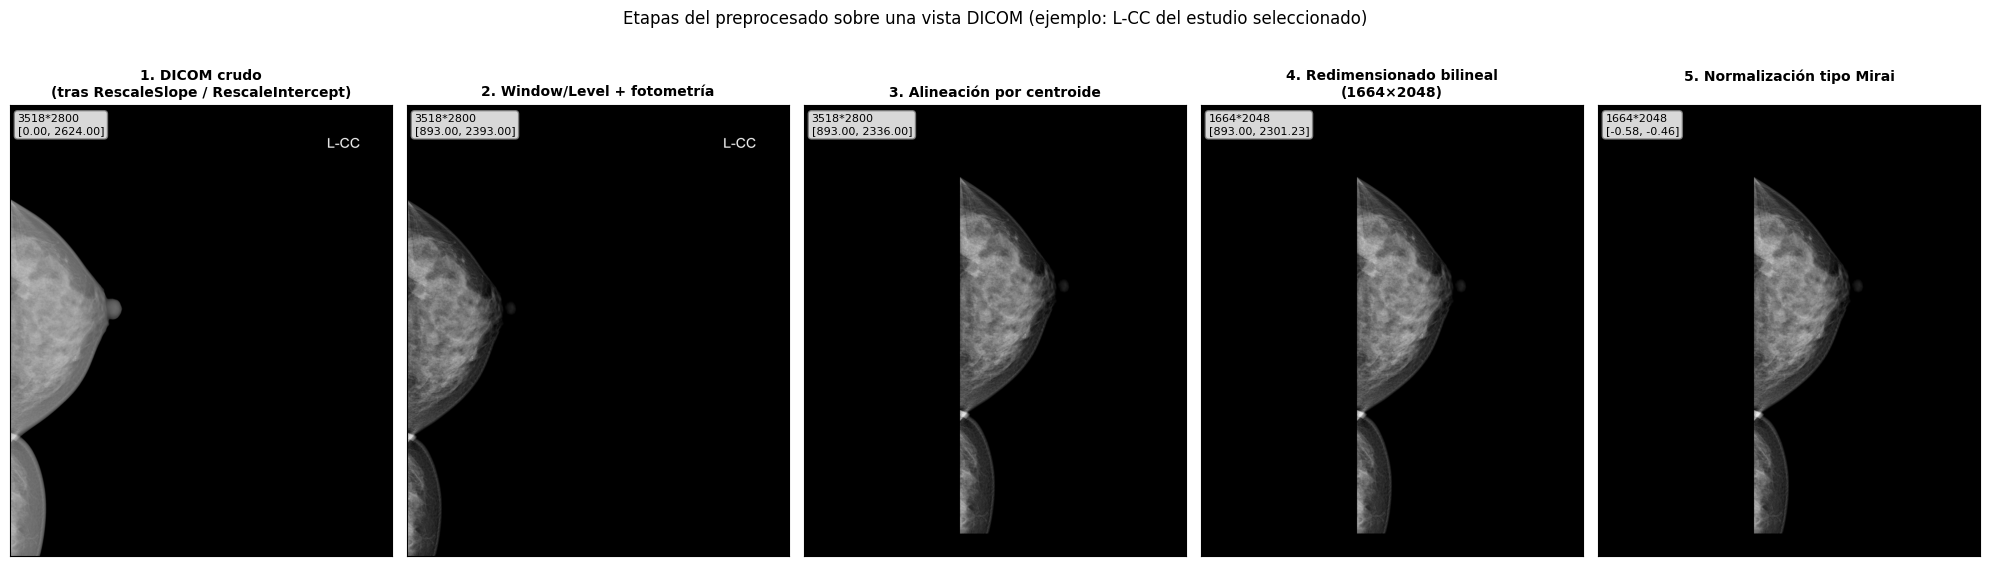


Guardado: c:\Users\victo\Documents\TFM\Proyecto\outputs\Features\preprocesado_etapas.png


In [11]:
import matplotlib.pyplot as plt

def preprocess_view_with_stages(dcm_path):
    ds = pydicom.dcmread(dcm_path)
    stages = {}

    # 1) DICOM crudo + RescaleSlope/Intercept
    pixels = ds.pixel_array.astype(np.float32)
    pixels = pixels * float(getattr(ds, 'RescaleSlope', 1)) + float(getattr(ds, 'RescaleIntercept', 0))
    stages['1_dicom_crudo'] = pixels.copy()

    # 2) Window/Level + fotometría
    if hasattr(ds, 'WindowCenter') and hasattr(ds, 'WindowWidth'):
        wc = float(ds.WindowCenter[0]) if hasattr(ds.WindowCenter, '__iter__') else float(ds.WindowCenter)
        ww = float(ds.WindowWidth[0])  if hasattr(ds.WindowWidth,  '__iter__') else float(ds.WindowWidth)
        pixels = np.clip(pixels, wc-ww/2, wc+ww/2)
    if getattr(ds, 'PhotometricInterpretation', '') == 'MONOCHROME1':
        pixels = pixels.max() - pixels
    stages['2_window_level'] = pixels.copy()

    # 3) Alineación por centroide
    _bg = float(pixels.min())
    _h, _w = pixels.shape
    _mask = (pixels > pixels.mean()).astype(np.uint8)
    _M = cv2.moments(_mask)
    if _M['m00'] != 0:
        _cy = int(_M['m01']/_M['m00']); _cx = int(_M['m10']/_M['m00'])
        _M_aff = np.float32([[1,0,_w//2-_cx],[0,1,_h//2-_cy]])
        pixels = cv2.warpAffine(pixels, _M_aff, (_w, _h), borderValue=_bg)
    stages['3_alineacion'] = pixels.copy()

    # 4) Redimensionado bilineal
    pixels = cv2.resize(pixels, (TARGET_W, TARGET_H), interpolation=cv2.INTER_LINEAR)
    stages['4_redimensionado'] = pixels.copy()

    # 5) Normalización tipo Mirai
    pixels = (pixels - MIRAI_MEAN) / MIRAI_STD
    stages['5_normalizado'] = pixels.copy()

    return stages

_vista_ejemplo = ('L', 'CC')
_dcm_path_ejemplo = vistas[_vista_ejemplo]
print(f'Vista de ejemplo: {_vista_ejemplo}, {os.path.basename(_dcm_path_ejemplo)}')

_stages = preprocess_view_with_stages(_dcm_path_ejemplo)

# Resumen
print(f'\n{"Etapa":<32}{"Shape":<20}{"Rango":<28}{"dtype"}')
print('-' * 90)
for name, img in _stages.items():
    r = f'[{img.min():.3f}, {img.max():.3f}]'
    print(f'  {name:<30}{str(img.shape):<20}{r:<28}{img.dtype}')

_titles = {
    '1_dicom_crudo': '1. DICOM crudo\n(tras RescaleSlope / RescaleIntercept)',
    '2_window_level': '2. Window/Level + fotometría',
    '3_alineacion': '3. Alineación por centroide',
    '4_redimensionado': f'4. Redimensionado bilineal\n({TARGET_H}×{TARGET_W})',
    '5_normalizado': '5. Normalización tipo Mirai\n',
}

fig, axes = plt.subplots(1, 5, figsize=(20, 5.5))
for ax, (key, img) in zip(axes, _stages.items()):
    ax.imshow(img, cmap='gray', aspect='auto')
    ax.set_title(_titles[key], fontsize=10, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    _txt = f'{img.shape[0]}*{img.shape[1]}\n[{img.min():.2f}, {img.max():.2f}]'
    ax.text(0.02, 0.98, _txt, transform=ax.transAxes, fontsize=8, va='top', ha='left', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='gray'))

fig.suptitle(f'Etapas del preprocesado sobre una vista DICOM (ejemplo: {_vista_ejemplo[0]}-{_vista_ejemplo[1]} del estudio seleccionado)', fontsize=12, y=1.02)
plt.tight_layout()

# Guardar
_features_dir = os.path.join(BASE, 'outputs', 'Features')
os.makedirs(_features_dir, exist_ok=True)
_out_path = os.path.join(_features_dir, 'preprocesado_etapas.png')
plt.savefig(_out_path, dpi=140, bbox_inches='tight')
plt.show()
print(f'\nGuardado: {_out_path}')
